# [Bacterial Colony Growth](@id Bacteries)

In this example, we are going to create a bacterial model and grow a colony using it.

 - The implementation of the force interaction dynamics is the one presented by [Volfson et al. (2008)](https://www.pnas.org/doi/abs/10.1073/pnas.0706805105)
 - We use GPU accelerated dynamics

As described in other models, it is advised that the models are constructed by parts to avoid having to find bugs in a very complex system. Hence, we will split the model in two parts:

 - Forces model
 - Growth model

## Load the packages

In [1]:
using Base.Threads
println("Usando ", nthreads(), " threads 😎")

Usando 1 threads 😎


In [2]:
# import Pkg
# Pkg.activate("../")
# Pkg.instantiate()


In [3]:
# import Pkg; Pkg.add(["Revise", "GLMakie"])

In [4]:
# using Revise
# using CellBasedModels
# using CUDA
# using Distributions
# using GLMakie
# # using GeometryBasics
# import GLMakie: Point3f, Cylinder, Sphere, NoShading #Can be changes to Cairo or CLMakie

In [5]:
import Pkg

# Activa el entorno del proyecto
Pkg.activate("../../../")


# Resuelve y asegura dependencias
Pkg.resolve()
Pkg.instantiate()


# Carga los paquetes de forma ordenada
using Revise
using CellBasedModels
ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false  # (opcional, fuerza compilación local)
using CUDA
CUDA.set_runtime_version!(v"12.2")
using Distributions
using CairoMakie
using JSON

# Importa funciones específicas después
import CairoMakie: Point3f, Cylinder, Sphere, NoShading

CairoMakie.activate!()


  Activating project at `~/Escritorio/Projects/Pushing/ABM_CBM`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Project.toml`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Manifest.toml`
┌ Info: Configure the active project to use CUDA 12.2; please re-start Julia for this to take effect.
└ @ CUDA /home/julia/.julia/packages/CUDA/jdJ7Z/lib/cudadrv/version.jl:82


## Forces model

We already use the defined forces model that is implemented in CBqodels. This is an exact copy of the rod model that you can find already predefined in `Models/rods.jl`. You can check the `Models` section of the documentation for more details.


In [6]:
rod2D = ABM(2,
    agent = Dict(
            :theta=>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :W=>Float64,
            :eta=>Float64,
        ),    #Local Interaction Parameters

    model = Dict(
            :E=>Float64,
        ),        #Global parameters

    agentODE = quote

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij
            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=GPU(),
    agentAlg = CBMIntegrators.Heun()
);


### Initialize a coqunity with two bacteries and check forces

In [7]:
com = Community(rod2D,
            N=30,
            dt=0.0001,
            simBox = [-10 10;-10 10.],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=6* 1.E5 *m/(t^2*d) #Pa
com.eta=150 *m/(t^2*d) #Pa h
 

com.d = 1.        
com.l = 3.99      



com.x = 0
com.y = 0
com.theta = 0;


In [8]:
com.N

30

In [9]:
for i in 1:com.N
    com.theta[i] = rand() * 2π
    com.x[i] = rand()*10-5
    com.y[i] = rand()*10-5
    com.l[i] = 3.0
    com.d[i] = 1.0

end

In [10]:
evolve!(com,steps=10000,saveEach=100,preallocateAgents=com.N)

In [11]:
function plotAgents2D!(ax, x, y, d, l, angle, p; colormap=:inferno, kargs...)
    for (xi, yi, li, di, ai, pi) in zip(x, y, l, d, angle, p)



            colorval = pi
            # colormap = :inferno
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [colorval],
                colormap = colormap,
                kargs...
            )

    end
    return
end


plotAgents2D! (generic function with 1 method)

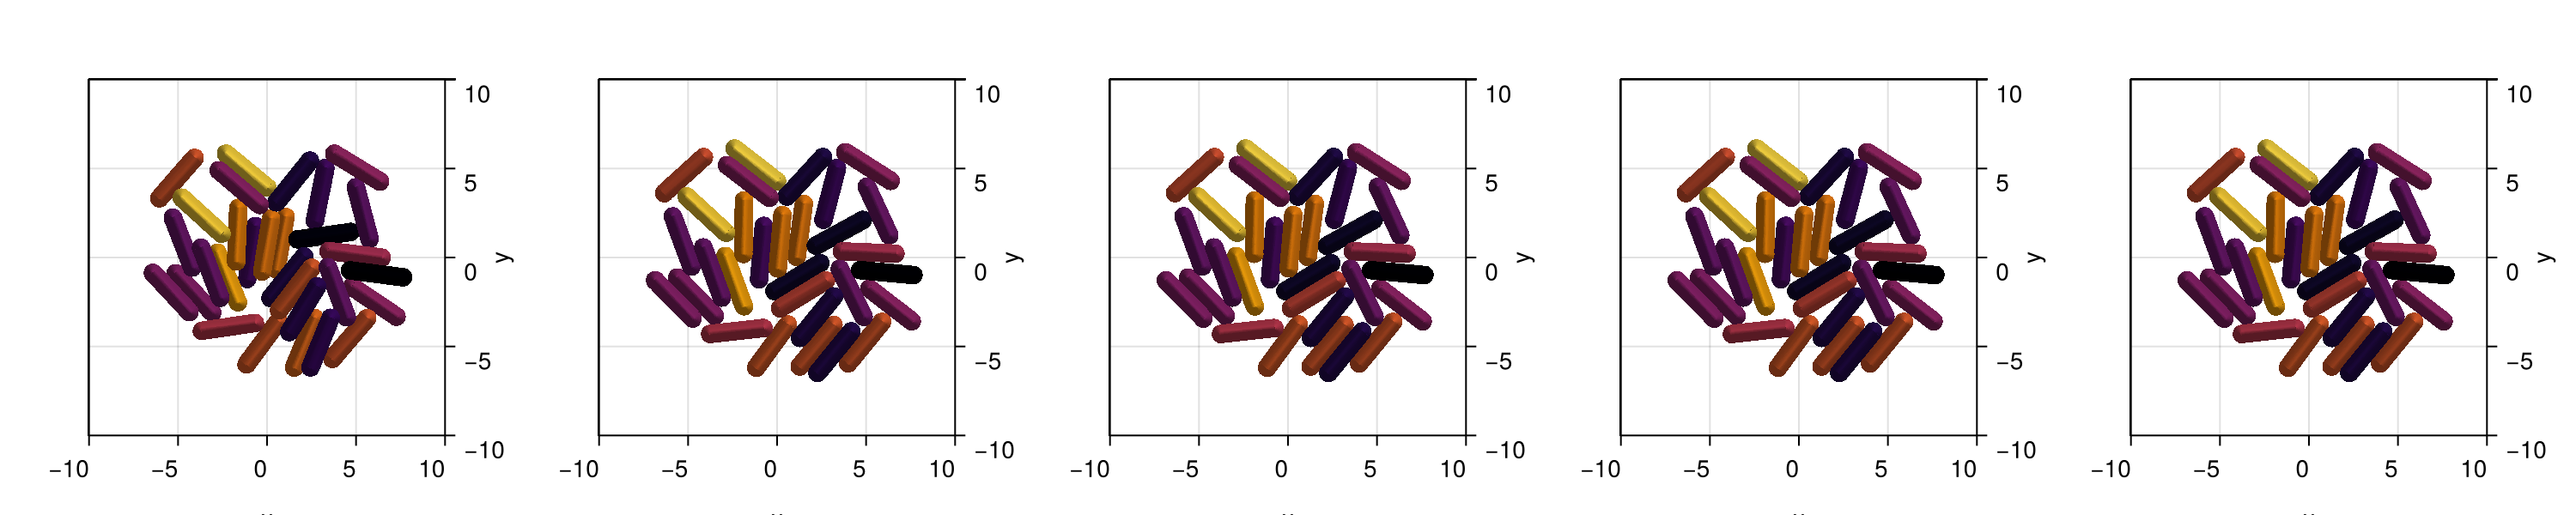

CairoMakie.Screen{IMAGE}


In [12]:
fig = Figure(size=(1500,300))

for (i,j) in enumerate([1:round(Int,length(com)/4):length(com);length(com)])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com[j][:x],
    com[j][:y],
    com[j][:d],
    com[j][:l],
    com[j][:theta],
    com[j][:theta],
    colorrange = (0, 2*pi)
)

    xlims!(-10,10)
    ylims!(-10,10)
end

display(fig)

In [13]:

function log_community_state(parameters::OrderedDict, t::Int, path::String = "Tods_c.txt")
    # Convert keys to strings so JSON can serialize them
    string_keys = Dict(string(k) => v for (k, v) in parameters)
    # Build entry
    entry = Dict("t" => t, "parameters" => string_keys)
    # Save as a JSON line
    open(path, "a") do io
        println(io, JSON.json(entry))
    end
end


function load_parameters_log(path::String = "Tods_c.txt")
    log = Dict{Int, OrderedDict{Symbol, Any}}()
    for line in eachline(path)
        entry = JSON.parse(line)
        t = entry["t"]
        raw_params = entry["parameters"]
        params = OrderedDict(Symbol(k) => v for (k, v) in raw_params)
        log[t] = params
    end
    times = sort(collect(keys(log)))
    com_array = [log[t] for t in times]
    return com_array, times
end



load_parameters_log (generic function with 2 methods)

## Growth model

We construct over the forces model to add bacterial growth and cell division rules.

In [14]:
function plotMixedAgents2D!(ax, x, y, d, l, angle, type, p; kargs...)
    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)


        if ti== 0  # rods
            # colorval = pi
            # colormap = :Blues
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:blue],
                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:blue],

                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:blue],

                kargs...
            )
        else  # puntos
            colorval = pi
            colormap = :Reds
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:red],
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:red],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:red],
                colormap = colormap,
                kargs...
            )
        end

    end
    return
end


plotMixedAgents2D! (generic function with 1 method)

In [15]:
rods2dGrowth = ABM(2,
    baseModelInit = [rod2D],

    agent = Dict(
                :dg=> Float64, 
                :lTarget => Float64,
                :type => Int,
                :growth=>Float64,
                :generation => Int,
            ),

    model = Dict(
                :σlTarget=>Float64,
                :lMax=>Float64,
                :stressed=> Bool,
                :computed=> Bool,
                :rmax => Float64, #Maximum radius of the cell
            ),
    
    # medium = Dict(
    #     :c => Float64,        #Add a medium parameter
    # ),

    agentODE = quote   
        if !stressed 
            dt(l) = l*growth #linear growth with growth dependent on the pressure over the cell
        else
            dt(l) = l*growth*((x^2+y^2)/(x^2+y^2 + rmax/4))
        end

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin
            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij
            if !computed
                if rmax < x^2+y^2
                    rmax = x^2+y^2 #Update the maximum radius of the cell
                end
            end
        end
        computed = true #Set the computed flag to true so that the maximum radius is not updated again
        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    agentRule = quote #Bound cells
        #Add division
        if l > lTarget
            ww = CBMDistributions.uniform(-1,1)*1.E-2 #To add some random torque at division time

            # ww = 0 #To add some random torque at division time
            #Add a new cell
            @addAgent(
                    x=(l+d)/4*cos(theta)+x,
                    y=(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    W=ww,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget),
                    dg=dg,
                    generation = generation + 1)
            #Add a second cell
            @addAgent(
                    x=-(l+d)/4*cos(theta)+x,
                    y=-(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget), #New target length at which the bactery should divide
                    W=ww,
                    dg=dg,
                    generation = generation + 1)
            #Remove the old cell
            @removeAgent()
        end
        
  
    end,

    #Medium dynamics with dirichlet conditions and a wall that is as oscillating source of material
    # mediumODE=quote 
    #     if @mediumInside()
    #         dt(c) = D_c*(@∂2(1,c)+@∂2(2,c)) - alpha_c*(c - cm)
    #     elseif @mediumBorder(1,-1)
    #         c = cm
    #     elseif @mediumBorder(1,1)
    #         c = cm
    #     elseif @mediumBorder(2,-1)
    #         c = cm
    #     elseif @mediumBorder(2,1)
    #         c = cm
    #     end

    # end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=GPU(),
    agentAlg=CBMIntegrators.Heun(),
    # mediumAlg=DifferentialEquations.Euler(),
);

## Grow colony from one cell

In [16]:
com = Community(rods2dGrowth,
            N=1,
            dt=0.0001,
            simBox = [-100 100;-100 100.],
            # NMedium=[100,100],
            );

#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=1* 1.E6 *m/(t^2*d) #Pa
com.eta=200 *m/(t^2*d) #Pa h
 
com.growth = 5
com.lMax = 4.     
com.σlTarget = 1. 
com.generation = 0 
 
com.d = 1.        
com.l = 3.99      
com.lTarget = 4.  

com.x = 0
com.y = 0
com.theta = 0;
com.rmax =0
com.computed = true
com.stressed = false

false

In [17]:
steps=Int(round(2/com.dt))
# saveEach=steps/100
saveEach=Int(round(10/com.dt))/100
# steps=100000
# saveEach=10000
N=100 

loadToPlatform!(com,preallocateAgents=N)
open("Tods_c.txt", "w") do f
    # clear file at start
end

for step in 1:steps
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end

bringFromPlatform!(com)


Step 1000 N: 2
Step 2000 N: 3
Step 3000 N: 4
Step 4000 N: 6
Step 5000 N: 8
Step 6000 N: 14
Step 7000 N: 16
Step 8000 N: 23
Step 9000 N: 32
Step 10000 N: 55
Step 11000 N: 65
Step 12000 N: 111
Step 13000 N: 130
Step 14000 N: 224
Step 15000 N: 263
Step 16000 N: 442
Step 17000 N: 540
Step 18000 N: 898
Step 19000 N: 1095
Step 20000 N: 1813


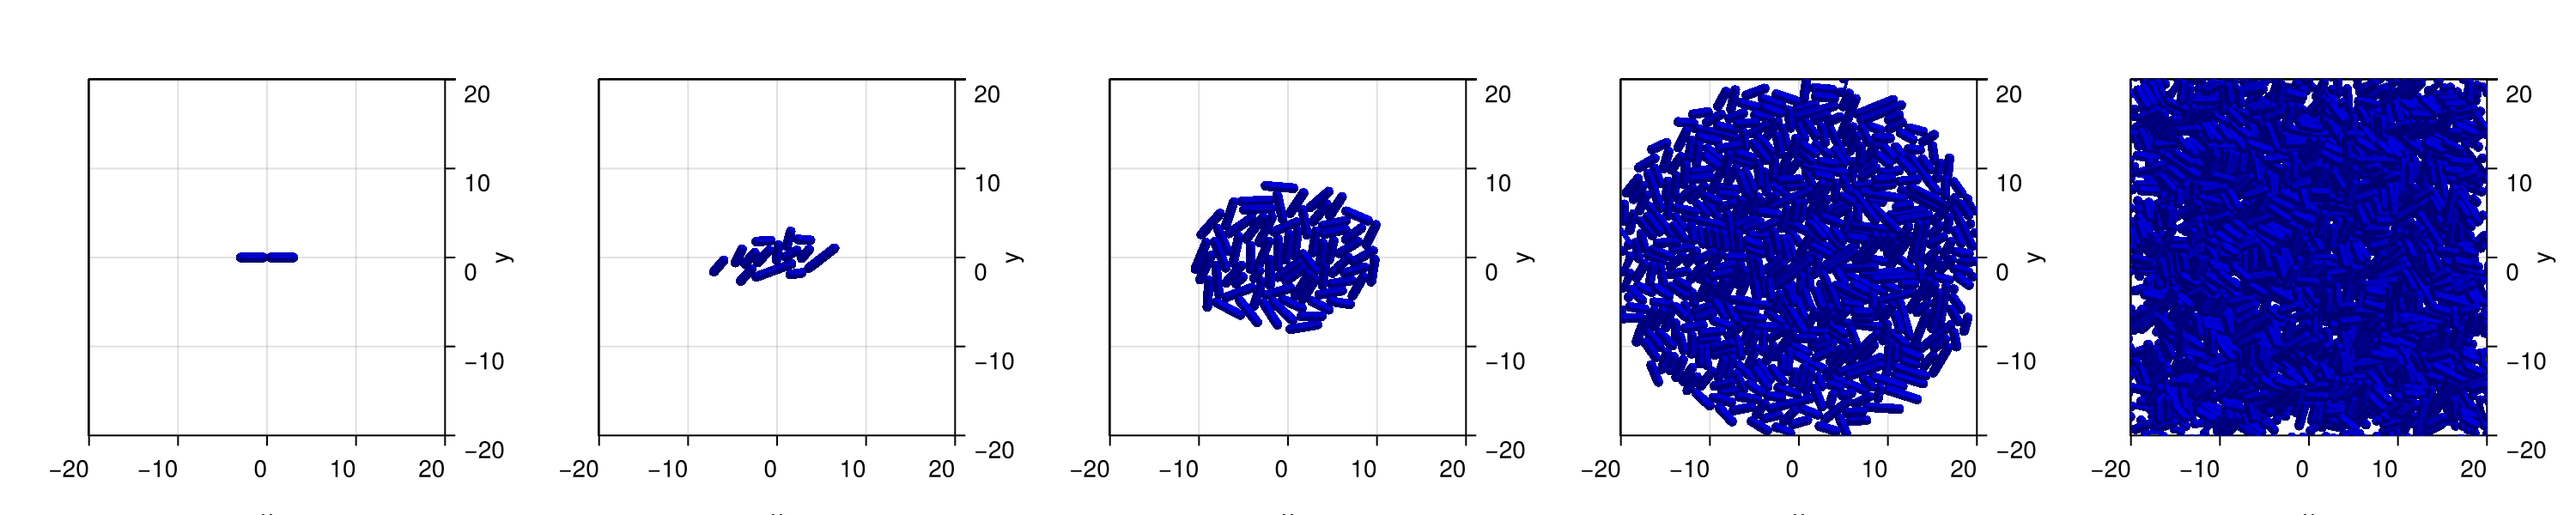

CairoMakie.Screen{IMAGE}


In [18]:
com_load,times=load_parameters_log("Tods_c.txt")

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-20,20)
    ylims!(-20,20)
end

display(fig)

In [19]:

prev_steps=steps
steps=Int(round(3/com.dt))
com.growth = 0

loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)


Step 21000 N: 1813
Step 22000 N: 1813
Step 23000 N: 1813
Step 24000 N: 1813
Step 25000 N: 1813
Step 26000 N: 1813
Step 27000 N: 1813
Step 28000 N: 1813
Step 29000 N: 1813
Step 30000 N: 1813


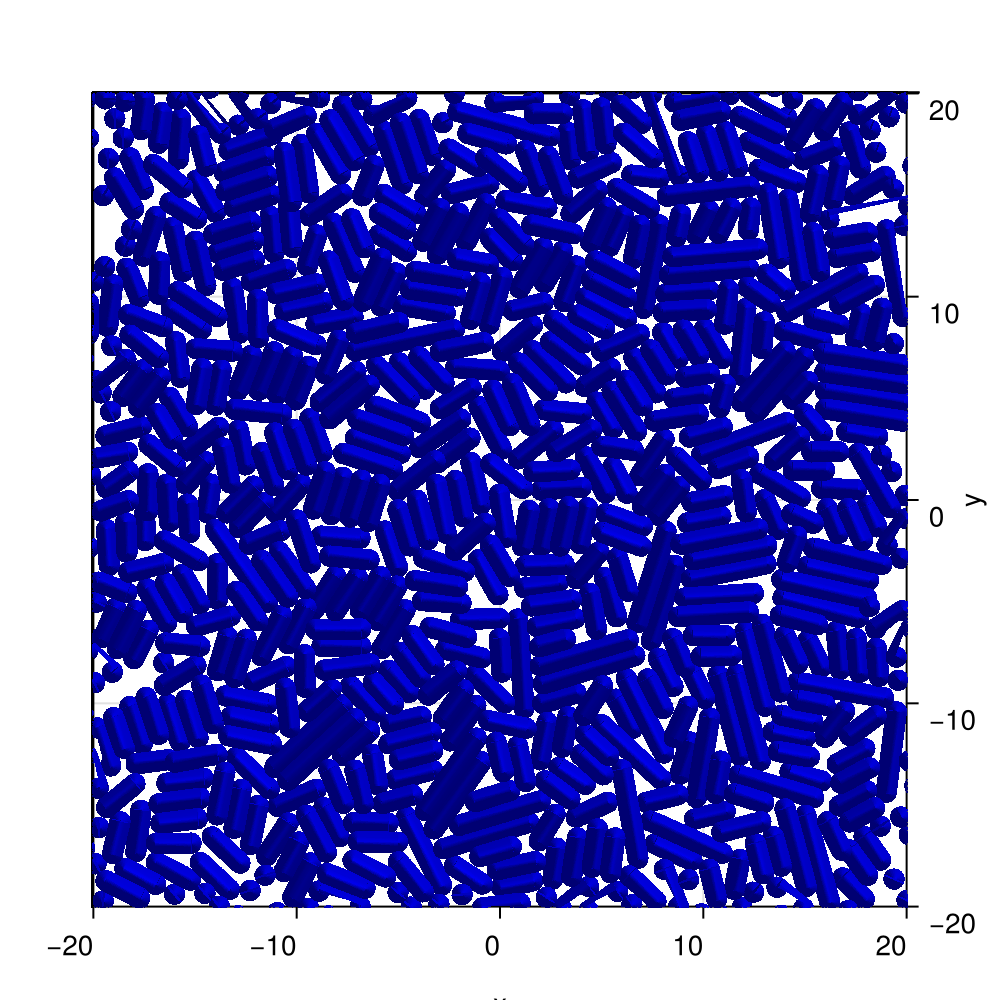

CairoMakie.Screen{IMAGE}


In [20]:
com_load,times=load_parameters_log("Tods_c.txt")

fig = Figure(size=(500,500))

js = length(com_load)
# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-20,20)
    ylims!(-20,20)
end

display(fig)

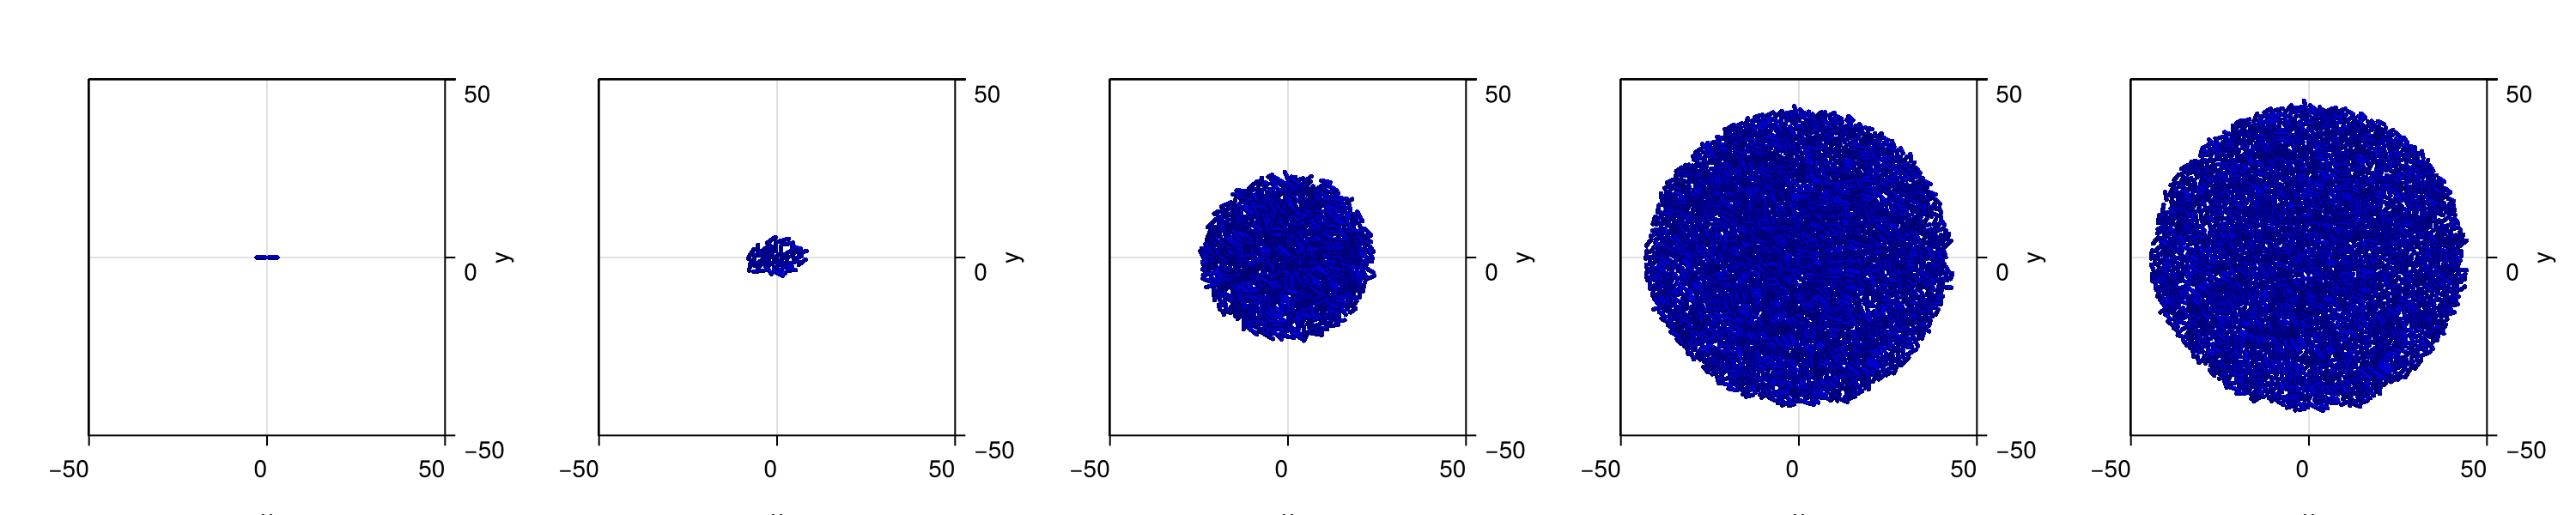

CairoMakie.Screen{IMAGE}


In [21]:
com_load,times=load_parameters_log("Tods_c.txt")

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

display(fig)

In [22]:
# bringFromPlatform!(com)

# idmax=findfirst(x -> x == maximum(com.x), com.x)
# com.type[idmax] = 1 #Change the type of the first cell to 1, so it can be identified as the first cell

# idmax=findfirst(x -> x == maximum(com.y), com.y)
# com.type[idmax] = 2 #Change the type of the first cell to 1, so it can be identified as the first cell

# idmax=findfirst(x -> x == minimum(com.x), com.x)
# com.type[idmax] = 3 #Change the type of the first cell to 1, so it can be identified as the first cell

# idmax=findfirst(x -> x == minimum(com.y), com.y)
# com.type[idmax] = 4 #Change the type of the first cell to 1, so it can be identified as the first cell
# println(sum(com.type .!= 0))
# log_community_state(com.parameters, steps)
# com_load,times=load_parameters_log("Tods_c.txt")


In [23]:
# cx, cy = 0, 15
# R2 = 100  # comparamos con el cuadrado del radio para evitar sqrt
# com.growth = 0.2
com.type =0
rmax = 0
for i in range(1,length(com.x))
    r = com.x[i]^2 + com.y[i]^2
    if r > rmax
        rmax = r
    end
    theta = atan(com.y[i], com.x[i])
    R =  400*exp(-50*theta^(2))+ 400
    prob = R^6/(R^6+r^6)
    if prob > rand()
        com.type[i] = 1
        com.growth[i] = 0.5
    else
        com.type[i] = 0
        com.growth[i] = 0.2
    end
end
com.rmax = rmax
com.computed = false
com.stressed = true
println(sum(com.type .== 1))
log_community_state(com.parameters, steps)
com_load,times=load_parameters_log("Tods_c.txt")




451


(OrderedDict{Symbol, Any}[OrderedDict(:W => Any[0.00022247481683734804, 0.00022247481683734804], :fx => Any[-6.03084135055542, 6.03084135055542], :x => Any[-1.7077271938323975, 1.7077271938323975], :stressed => Any[false], :σlTarget => Any[1.0], :theta => Any[6.619020041398471e-6, 6.619020041398471e-6], :d => Any[1.0, 1.0], :growth => Any[5.0, 5.0], :y => Any[3.431041704970994e-6, -3.431041704970994e-6], :computed => Any[true]…), OrderedDict(:W => Any[0.0, 3.894608653354226e-6, 3.8946736822254024e-6], :fx => Any[0.0, -3.5935873985290527, 3.5935873985290527], :x => Any[-2.263068437576294, 1.0431921482086182, 3.481187343597412], :stressed => Any[false], :σlTarget => Any[1.0], :theta => Any[0.00018855232337955385, 0.00018673377053346485, 0.00018673377053346485], :d => Any[1.0, 1.0, 1.0], :growth => Any[5.0, 5.0, 5.0], :y => Any[0.00014627384371124208, -0.0003726499853655696, 8.186019113054499e-5], :computed => Any[true]…), OrderedDict(:W => Any[0.0, 0.0, 0.0, 0.0], :fx => Any[0.0, 0.0, 0.

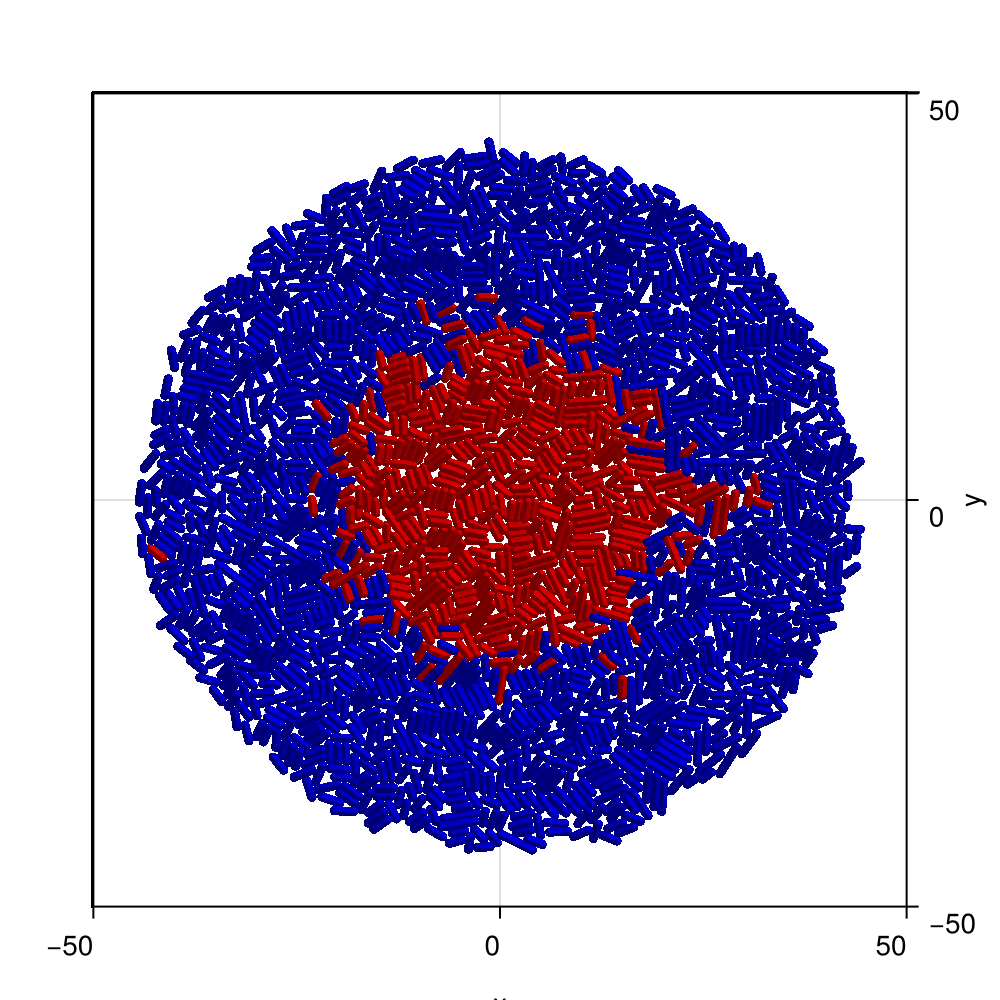

CairoMakie.Screen{IMAGE}


In [24]:
fig = Figure(size=(500,500))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

display(fig)

In [25]:
for i in range(1,length(com.x))
    r = com.x[i]^2 + com.y[i]^2
    if com.type[i] == 1
        com.growth[i] = 0.5*r/(rmax/4 + r)
    else
        com.growth[i] = 0.2*r/(rmax/4 + r)
    end
end
log_community_state(com.parameters, steps)

open("Motiles.txt", "w") do f
    # clear file at start
end
log_community_state(com.parameters, steps, "Motiles.txt")


In [39]:
prev_steps=steps
steps=Int(round(25/com.dt))

loadToPlatform!(com,preallocateAgents=2*com.N[1])


for step in 1+prev_steps:steps
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step, "Motiles.txt")
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)


Step 195000 N: 5535
Step 196000 N: 5578
Step 197000 N: 5632
Step 198000 N: 5680
Step 199000 N: 5717
Step 200000 N: 5762
Step 201000 N: 5795
Step 202000 N: 5844
Step 203000 N: 5884
Step 204000 N: 5917
Step 205000 N: 5956
Step 206000 N: 6007
Step 207000 N: 6049
Step 208000 N: 6090
Step 209000 N: 6132
Step 210000 N: 6188
Step 211000 N: 6229
Step 212000 N: 6271
Step 213000 N: 6326
Step 214000 N: 6377
Step 215000 N: 6423
Step 216000 N: 6473
Step 217000 N: 6533
Step 218000 N: 6591
Step 219000 N: 6643
Step 220000 N: 6708
Step 221000 N: 6761
Step 222000 N: 6832
Step 223000 N: 6882
Step 224000 N: 6954
Step 225000 N: 7013
Step 226000 N: 7079
Step 227000 N: 7159
Step 228000 N: 7247
Step 229000 N: 7316
Step 230000 N: 7382
Step 231000 N: 7459
Step 232000 N: 7536
Step 233000 N: 7611
Step 234000 N: 7688
Step 235000 N: 7760
Step 236000 N: 7836


InterruptException: InterruptException:

In [40]:
com_load,times=load_parameters_log("Motiles.txt")


(OrderedDict{Symbol, Any}[OrderedDict(:W => Any[-1.885465145111084, -0.36170583963394165, -0.02299216389656067, -0.3920155465602875, 8.020770072937012, -18.011655807495117, 5.101294994354248, -2.308293342590332, 51.01184844970703, -0.4814344048500061  …  13.045236587524414, -0.740035355091095, 65.38996124267578, 0.09189905226230621, -3.8647689819335938, -1.099461555480957, 3.9831361770629883, 4.133712291717529, 6.172153472900391, -12.907373428344727], :fx => Any[-0.1010790541768074, -0.37470370531082153, -2.3732612133026123, 1.618470311164856, 0.0015085532795637846, -0.8175264596939087, 1.0789361000061035, -0.9355040192604065, 3.9090402126312256, -0.5395376086235046  …  -3.894822597503662, -1.762913703918457, -0.17275837063789368, -2.5055947303771973, 0.5722560882568359, -5.051340103149414, 0.522365152835846, -6.040470600128174, 3.662435293197632, -0.10185010731220245], :x => Any[-3.103821039199829, -9.968316078186035, -3.7305517196655273, 30.266530990600586, 24.19621467590332, -29.173

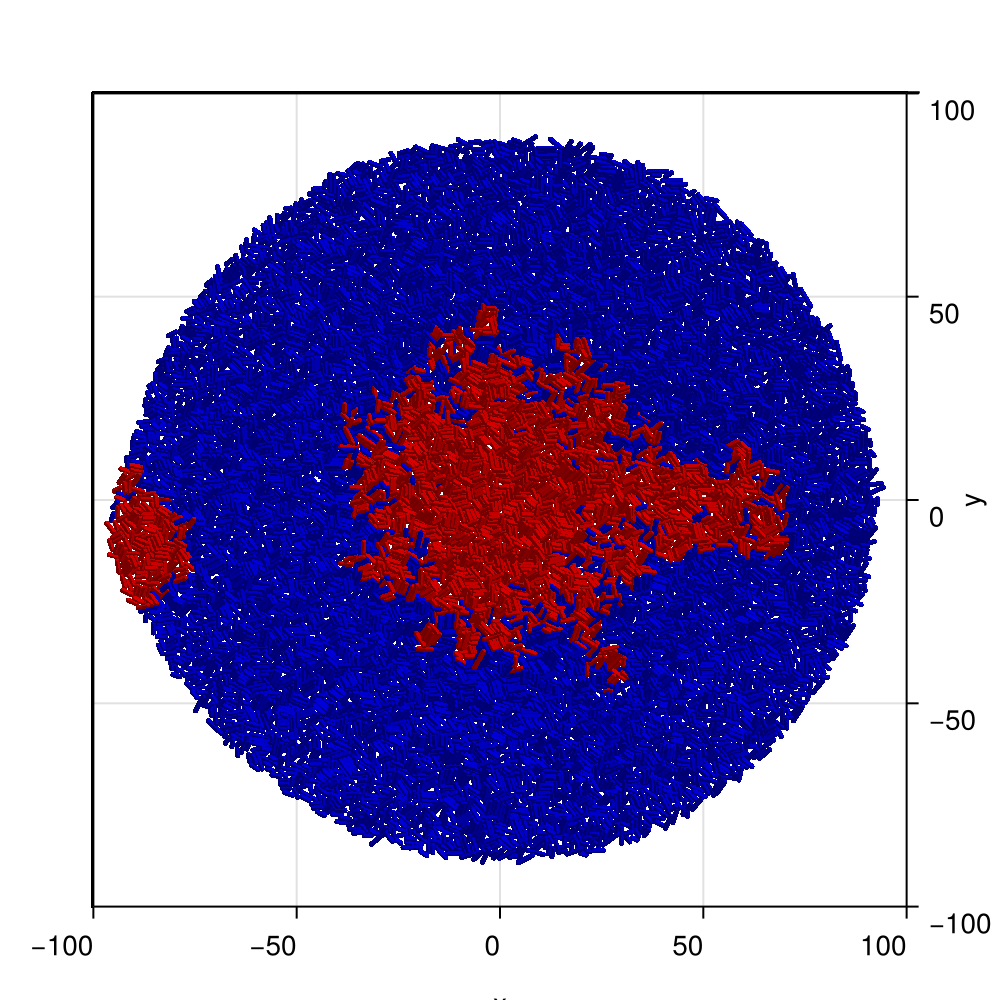

CairoMakie.Screen{IMAGE}


In [42]:
# Colormap común y colorrange fijo
# colormap = :viridis
# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))



fig = Figure(size=(500,500))

js = length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    # m = heatmap!(ax,
    #             range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
    #             range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
    #             Float64.(hcat(com_load[j][:q]...)),
    #             colormap = colormap,
    #             colorrange = colorrange
    #         )
    

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
# Colorbar(fig[1, length(js) + 1],
#     colormap = colormap,
#     colorrange = colorrange,
#     label = "QS"
# )

display(fig)

In [37]:
function plotMixedAgents!(ax, x, y, d, l, angle, type, p; kargs...)
    # Diccionario de tipos a colormaps (puedes extenderlo con más tipos y colores)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)
        # Colormap según tipo, o uno genérico si no está definido
        colormap = get(colormap_dict, ti, :viridis)

        # Color numérico según p
        colorval = pi

        # Esferas en los extremos
        for dx in (-1, 1)
            meshscatter!(ax,
                [xi + dx * li/2 * cos(ai)],
                [yi + dx * li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = colorval,
                colormap = colormap,
                kargs...
            )
        end

        # Cuerpo alargado
        meshscatter!(ax,
            [xi],
            [yi];
            marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
            markersize = [Point3f(li, di/2, di/2)],
            rotation = [ai],
            color = colorval,
            colormap = colormap,
            kargs...
        )
    end
    return
end


plotMixedAgents! (generic function with 1 method)

In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.c)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    

    plotMixedAgents!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:generation],
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
# Colorbar(fig[1, length(js) + 1],
#     colormap = colormap,
#     colorrange = colorrange,
#     label = "QS"
# )

display(fig)

In [45]:
function plot_evolution_by_type_from_positions(com)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    tipos = unique(com[end][:type])
    tipos = sort(tipos)[2:end]

    first_gen = Dict{Int, NamedTuple}()

    for t in sort(collect(keys(com)))
        for (i, ti) in enumerate(com[t][:type])
            if !(ti in keys(first_gen))
                first_gen[ti] = (
                    tiempo = t,
                    index = i,
                    x0 = com[t][:x][i],
                    y0 = com[t][:y][i]
                )
            end
        end
    end

    fig = Figure()
    ax = Axis(fig[1, 1], 
            xlabel = "θ",
            ylabel = "r",
            yreversed = true,
            )

    for t in sort(collect(keys(com)))
        com_t = com[t]

        for ti in tipos
            indices = findall(com_t[:type] .== ti)
            if isempty(indices)
                continue
            end

            f = first_gen[ti]
            x0, y0 = f.x0, f.y0
            gen0 = f.tiempo

            xs = com_t[:x][indices]
            ys = com_t[:y][indices]
            gens = fill(t - gen0, length(indices))

            distances = sqrt.((xs).^2 .+ (ys).^2)

            # Ángulo relativo calculado por desplazamiento
            angles = atan.(ys, xs)  



            colormap = haskey(colormap_dict, ti) ? colormap_dict[ti] : error("Tipo $ti no tiene colormap definido")

            scatter!(ax, angles, distances;
                color = gens,
                colormap = colormap,
                markersize = 10,
                label = "Tipo $ti",
                colorrange = (0, length(com)),
            )
        end
    end

    # axislegend(ax)
    return fig
end


plot_evolution_by_type_from_positions (generic function with 1 method)

In [46]:
function plot_evolution(com)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    tipos = unique(com[end][:type])
    tipos = sort(tipos)[2:end]

    first_gen = Dict{Int, NamedTuple}()

    for t in sort(collect(keys(com)))
        for (i, ti) in enumerate(com[t][:type])
            if !(ti in keys(first_gen))
                first_gen[ti] = (
                    tiempo = t,
                    index = i,
                    x0 = com[t][:x][i],
                    y0 = com[t][:y][i]
                )
            end
        end
    end

    fig = Figure(backgroundcolor = :black)  # Fondo negro

    ax = Axis(
        fig[1, 1],
        xlabel = "θ",  # Letra griega
        ylabel = "r",
        yreversed = true,
        backgroundcolor = :black,
        xlabelcolor = :white,
        ylabelcolor = :white,
        xticklabelcolor = :white,
        yticklabelcolor = :white,
        xtickcolor = :white,
        ytickcolor = :white,
        bottomspinecolor = :white,
        leftspinecolor = :white,
        rightspinecolor = :white,
        topspinecolor = :white
    )

    for t in sort(collect(keys(com)))
        com_t = com[t]

        for ti in tipos
            indices = findall(com_t[:type] .== ti)
            if isempty(indices)
                continue
            end

            f = first_gen[ti]
            x0, y0 = f.x0, f.y0
            gen0 = f.tiempo

            xs = com_t[:x][indices]
            ys = com_t[:y][indices]
            gens = fill(t - gen0, length(indices))

            distances = sqrt.((xs).^2 .+ (ys).^2)
            angles = atan.(ys, xs)

            colormap = get(colormap_dict, ti, :viridis)

            scatter!(ax, angles, distances;
                color = gens,
                colormap = colormap,
                markersize = 10,
                label = "Tipo $ti",
                colorrange = (0, length(com)),
            )
        end
    end

    return fig
end


plot_evolution (generic function with 1 method)

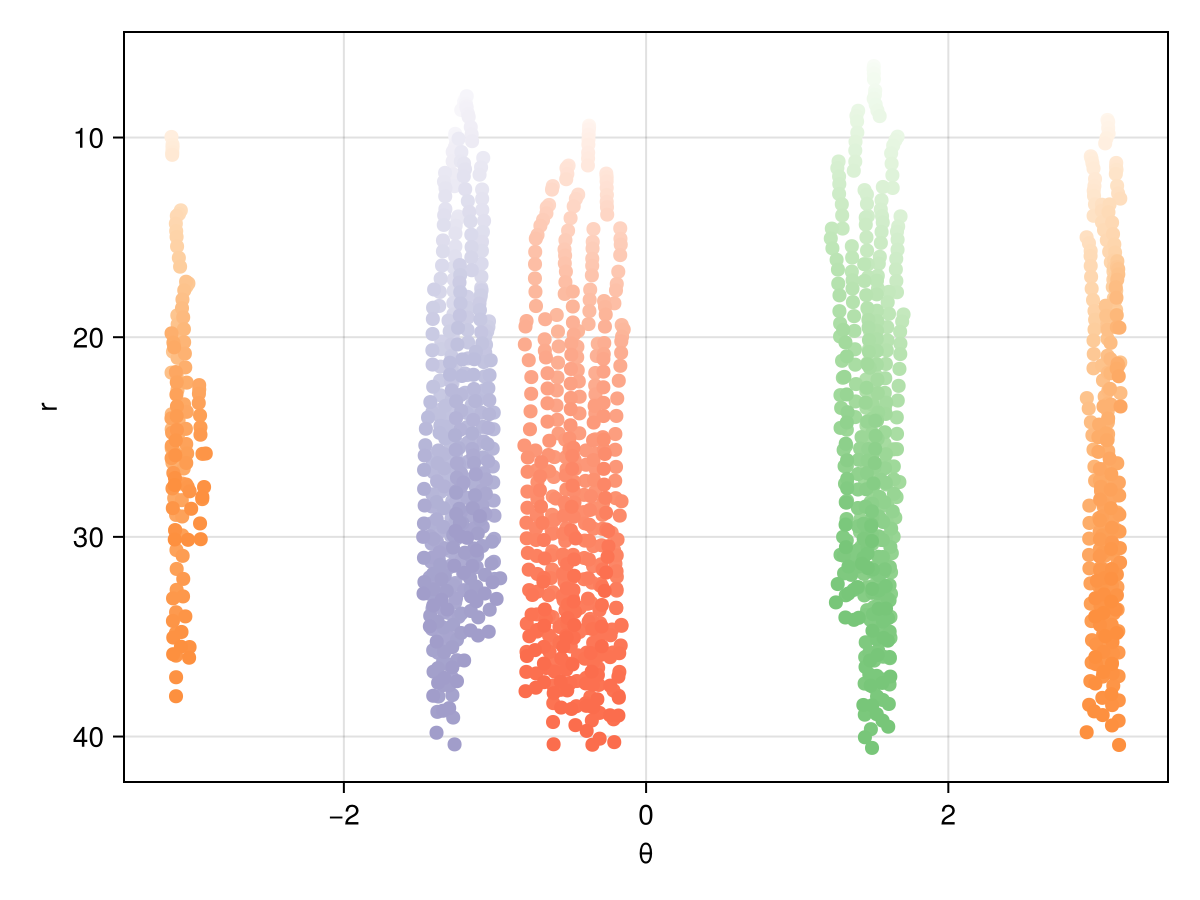

In [28]:
plot_evolution_by_type_from_positions(com_load)

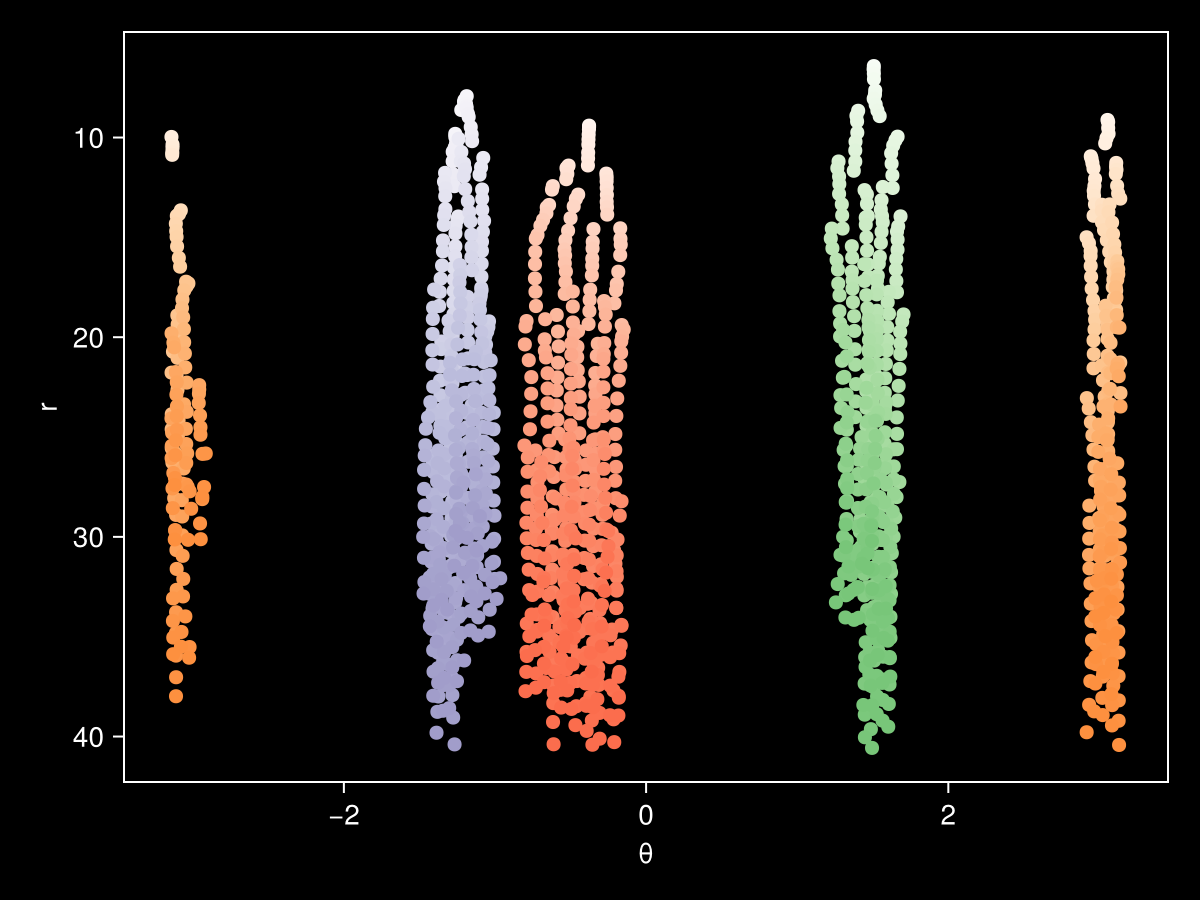

In [31]:
plot_evolution(com_load)


In [44]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())


# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colorrange = (0.0,  2.)

Makie.record(fig, "Tods.mp4", 1:10:Int(length(com_load)); framerate = 15) do j
 
    Makie.empty!(ax)
   
    plotMixedAgents!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:type],
        com_load[j][:d],
        colorrange = colorrange
    )


    xlims!(ax, -100, 100)
    ylims!(ax, -100, 100)
end


"Tods.mp4"